# 03 · Exploratory data analysis: pilot products

Reads `data/processed/aligned_daily.csv`, the Google Trends daily index for the pilot products joined with same-day YouTube observations (`src/build_aligned.py`). It describes the data; **it does not build model features or the project's surge label**, which belong to the modelling task.

Read before interpreting:
- **Relative scales.** Each product's Google Trends series is scaled to its own peak (= 100) in its own request, so levels are **not comparable across products**; shapes and changes within a product are.
- **pytrends zeros.** Trends data collected with pytrends has integer values, so a "<1" day shows as 0.
- **Partial last day.** The last day of a pytrends series can be partial (`isPartial`, recorded in `data/trends_collection_manifest.csv`). Such days are left out of the change and spike calculations below.
- **One YouTube snapshot.** YouTube has only one snapshot so far (main pass and 7-day recent pass on 2026-10-03), so any YouTube comparison is a cross-section of the pilot products, not a time series.

Charts are saved to `docs/figures/`.

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
ALIGNED = ROOT / "data" / "processed" / "aligned_daily.csv"
MANIFEST = ROOT / "data" / "trends_collection_manifest.csv"
FIGURES = ROOT / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
TYPE_ORDER = ["RISING", "STABLE", "DECLINING"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

if not ALIGNED.exists():
    raise SystemExit(f"{ALIGNED} does not exist yet: EDA is blocked until the Google Trends data is collected "
                     "and src/build_aligned.py has run. No charts were made.")

df = pd.read_csv(ALIGNED, parse_dates=["date"])
NEEDED = ["product_id", "date", "product_name", "product_type", "search_interest"]
missing = [c for c in NEEDED if c not in df.columns]
if missing:
    raise SystemExit(f"aligned table lacks required columns {missing}; no charts were made.")
for optional in ["trends_observed", "youtube_recent_observed", "videos_7d_on_target", "videos_published_7d"]:
    if optional not in df.columns:
        df[optional] = np.nan
        print(f"note: column {optional!r} missing in the aligned table; treated as empty")

df = df.sort_values(["product_id", "date"]).reset_index(drop=True)
df["label"] = df["product_id"] + " " + df["product_name"].fillna("")

# Mark partial days from the collection manifest (pytrends isPartial is in the native files only).
df["is_partial_day"] = False
if MANIFEST.exists():
    manifest = pd.read_csv(MANIFEST)
    partial = manifest[pd.to_numeric(manifest.get("partial_rows"), errors="coerce").fillna(0) > 0]
    for _, row in partial.iterrows():
        df.loc[(df["product_id"] == row["product_id"]) & (df["date"] == pd.Timestamp(row["last_date"])),
               "is_partial_day"] = True
complete = df[~df["is_partial_day"] & df["search_interest"].notna()].copy()

summary = df.groupby(["product_id", "product_name", "product_type"]).agg(
    days=("date", "nunique"), first=("date", "min"), last=("date", "max"),
    missing_values=("search_interest", lambda s: int(s.isna().sum())),
    zero_share=("search_interest", lambda s: round(float((s == 0).mean()), 3)),
    partial_days=("is_partial_day", "sum")).reset_index()
print(f"{len(df)} rows, {df['product_id'].nunique()} products")
summary

2690 rows, 10 products


,product_id,product_name,product_type,days,first,last,missing_values,zero_share,partial_days
0,P003,Apple iPhone Duo,RISING,269,2026-01-08,2026-10-03,0,0.907,1
1,P006,Samsung Galaxy Z Flip 8,RISING,269,2026-01-08,2026-10-03,0,0.859,1
2,P016,Poco X8 Power,RISING,269,2026-01-08,2026-10-03,0,0.859,1
3,P018,Vivo T5 5G,RISING,269,2026-01-08,2026-10-03,0,0.041,1
4,P035,OnePlus 15R,STABLE,269,2026-01-08,2026-10-03,0,0.000,1
5,P043,Realme GT 8 Pro,STABLE,269,2026-01-08,2026-10-03,0,0.100,1
6,P044,Motorola Edge 70,STABLE,269,2026-01-08,2026-10-03,0,0.000,1
7,P046,Oppo Reno 15,STABLE,269,2026-01-08,2026-10-03,0,0.000,1
8,P057,Google Pixel 9,DECLINING,269,2026-01-08,2026-10-03,0,0.000,1
9,P059,Redmi Note 14 Pro Plus,DECLINING,269,2026-01-08,2026-10-03,0,0.030,1


## a. How has search interest moved over the last nine months?

**Business question:** do rising, stable and declining products show visibly different search trajectories?

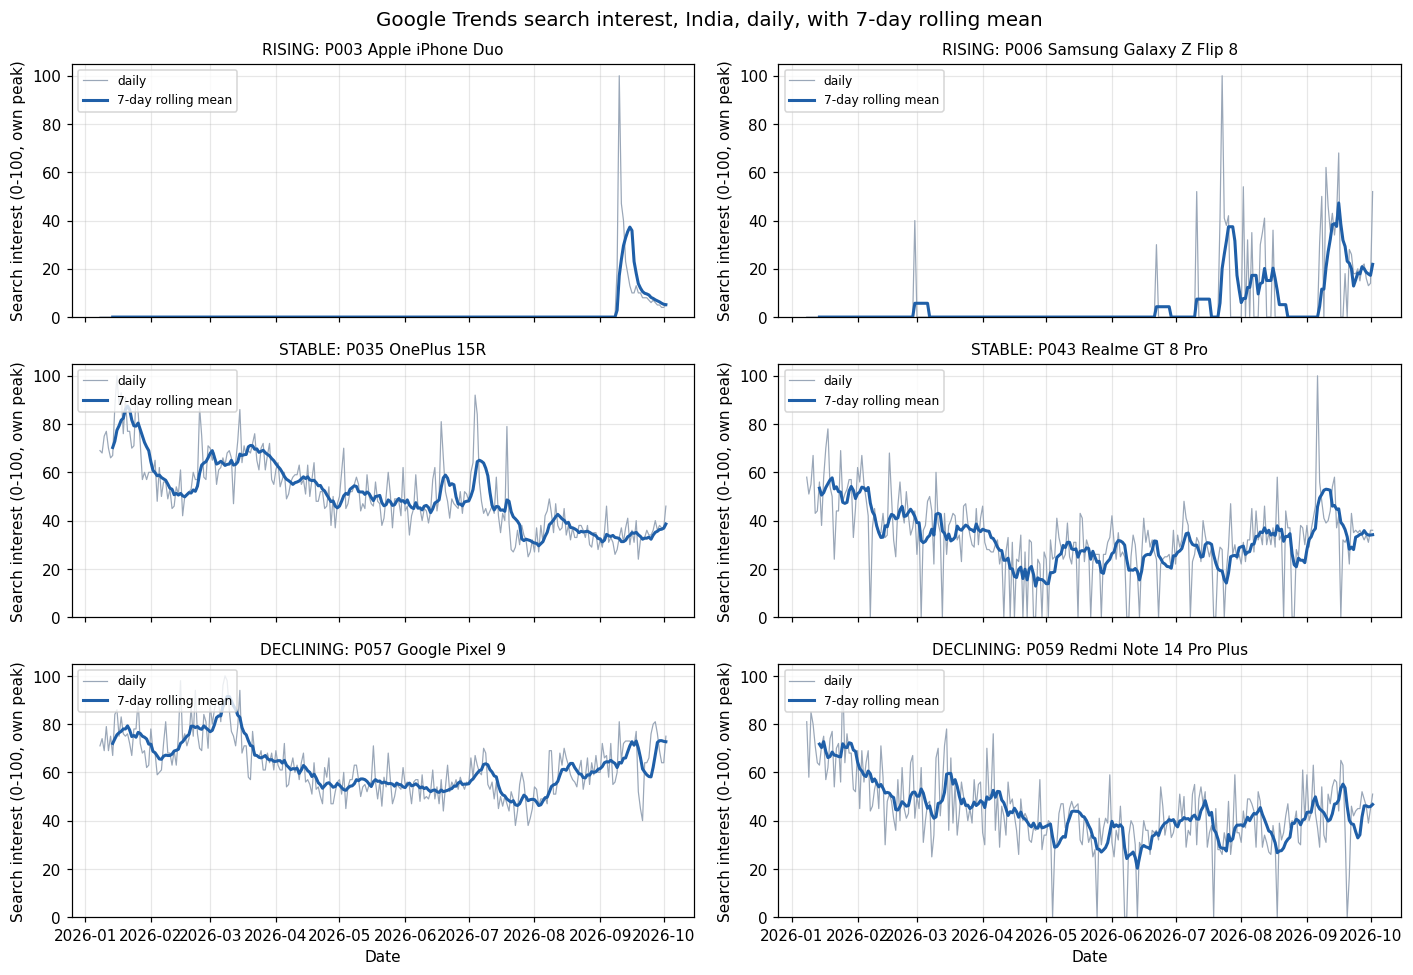

Products shown: P003, P006, P035, P043, P057, P059


In [2]:
picked = []
for ptype in TYPE_ORDER:
    ids = sorted(df.loc[df["product_type"] == ptype, "product_id"].unique())[:2]
    picked += [(ptype, pid) for pid in ids]
if not picked:
    print("No products with Trends data; chart a skipped.")
else:
    fig, axes = plt.subplots(len(TYPE_ORDER), 2, figsize=(13, 9), sharex=True, squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for ptype_row, ptype in enumerate(TYPE_ORDER):
        ids = [pid for t, pid in picked if t == ptype]
        for col, pid in enumerate(ids):
            ax = axes[ptype_row][col]
            ax.set_visible(True)
            s = complete[complete["product_id"] == pid].set_index("date")["search_interest"]
            ax.plot(s.index, s.values, color="#9aa7b8", lw=0.8, label="daily")
            ax.plot(s.index, s.rolling(7, min_periods=7).mean(), color="#1f5fa8", lw=2, label="7-day rolling mean")
            name = df.loc[df["product_id"] == pid, "label"].iloc[0]
            ax.set_title(f"{ptype}: {name}", fontsize=10)
            ax.set_ylabel("Search interest (0-100, own peak)")
            ax.set_ylim(0, 105)
            ax.legend(fontsize=8, loc="upper left")
    for ax in axes[-1]:
        ax.set_xlabel("Date")
    fig.suptitle("Google Trends search interest, India, daily, with 7-day rolling mean", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES / "eda_a_trends_by_type.png", bbox_inches="tight")
    plt.show()
    print("Products shown:", ", ".join(pid for _, pid in picked))

**Interpretation** (pilot run of 2026-10-04; the cell below prints the supporting numbers):
- **Launch spikes are sharp and short.** iPhone Duo (P003) is at zero until the 9 Sep announcement, peaks the next day, and its 7-day mean falls back to about 5 within three weeks. Galaxy Z Flip 8 (P006) shows a rumour blip in February, its launch peak on 23 Jul, and a second wave in September. For early detection, the window that matters is days, not months.
- **Stable products drift and are noisy.** OnePlus 15R (P035) slides from about 70 in January to about 35 (mean 53 before the last 28 days, 34 in them). Realme GT 8 Pro (P043) moves between 20 and 50, with a one-day spike on 6 Sep.
- **The registry type does not always match search behaviour.** Pixel 9 (P057, DECLINING) declines until August but rises again in September (last-28-day mean 67 vs 62 before). That is plausibly broad-match spill-over from the Pixel 11 launch, since `pixel 9` also matches sibling searches. Redmi Note 14 Pro Plus (P059) declines as expected (about 70 to about 40).
- Each panel is scaled to its own peak, so compare shapes, not heights.

In [3]:
facts = []
for ptype, pid in picked:
    s = complete[complete["product_id"] == pid].set_index("date")["search_interest"]
    if s.empty:
        continue
    peak_day = s.idxmax().date()
    first_nonzero = s[s > 0].index.min()
    last28, prev = s.iloc[-28:].mean(), s.iloc[:-28].mean()
    facts.append({"type": ptype, "product": pid, "peak_day": peak_day,
                  "first_nonzero_day": first_nonzero.date() if pd.notna(first_nonzero) else None,
                  "zero_share": round(float((s == 0).mean()), 2),
                  "mean_last_28d": round(last28, 1), "mean_before": round(prev, 1)})
pd.DataFrame(facts)

,type,product,peak_day,first_nonzero_day,zero_share,mean_last_28d,mean_before
0,RISING,P003,2026-09-10,2026-09-09,0.91,13.8,0.0
1,RISING,P006,2026-07-23,2026-02-28,0.86,24.8,2.7
2,STABLE,P035,2026-01-16,2026-01-08,0.00,34.3,53.0
3,STABLE,P043,2026-09-06,2026-01-08,0.10,39.7,31.8
4,DECLINING,P057,2026-03-08,2026-01-08,0.00,66.9,62.4
5,DECLINING,P059,2026-01-25,2026-01-08,0.03,43.6,44.0


## b. How volatile is day-to-day search interest?

**Business question:** are rising products' daily search swings larger than those of stable or declining products, which affects how noisy any early-warning signal will be?

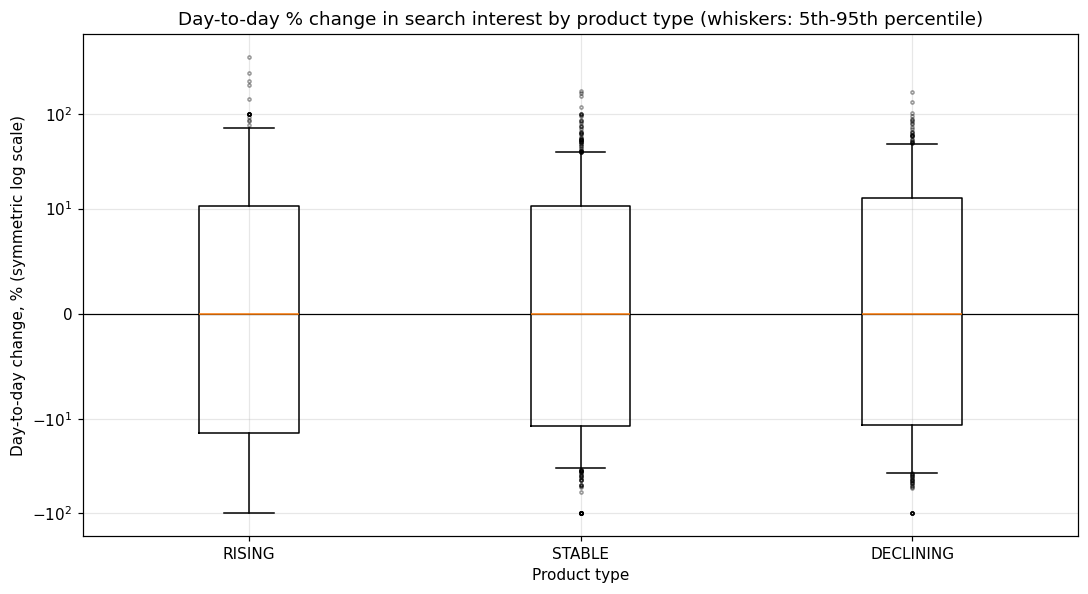

,count,mean,std,min,5%,50%,95%,max,undefined_from_zero
product_type,,,,,,,,,
RISING,351.0,-0.7,48.7,-100.0,-100.0,0.0,73.8,400.0,717
STABLE,1041.0,0.1,27.1,-100.0,-33.3,0.0,39.1,172.7,27
DECLINING,526.0,1.4,27.9,-100.0,-37.7,0.0,48.6,170.6,8


In [4]:
changes = []
for pid, g in complete.groupby("product_id"):
    g = g.sort_values("date")
    prev = g["search_interest"].shift(1)
    valid = prev > 0  # a change from 0 is undefined (division by zero), not an outlier
    pct = (g["search_interest"] - prev) / prev * 100
    changes.append(pd.DataFrame({"product_id": pid, "product_type": g["product_type"],
                                 "pct_change": pct.where(valid), "from_zero": (prev == 0)}))
changes = pd.concat(changes, ignore_index=True) if changes else pd.DataFrame(
    columns=["product_id", "product_type", "pct_change", "from_zero"])
defined = changes.dropna(subset=["pct_change"])
groups = [defined.loc[defined["product_type"] == t, "pct_change"] for t in TYPE_ORDER]
if defined.empty:
    print("No defined day-to-day changes; chart b skipped.")
else:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.boxplot(groups, tick_labels=TYPE_ORDER, showfliers=True, whis=(5, 95),
               flierprops={"markersize": 2, "alpha": 0.4})
    ax.set_yscale("symlog", linthresh=10)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Day-to-day % change in search interest by product type (whiskers: 5th-95th percentile)")
    ax.set_xlabel("Product type")
    ax.set_ylabel("Day-to-day change, % (symmetric log scale)")
    fig.tight_layout()
    fig.savefig(FIGURES / "eda_b_pct_change_by_type.png", bbox_inches="tight")
    plt.show()
stats = defined.groupby("product_type")["pct_change"].describe(percentiles=[.05, .5, .95]).reindex(TYPE_ORDER)
stats["undefined_from_zero"] = changes.groupby("product_type")["from_zero"].sum().reindex(TYPE_ORDER)
stats.round(1)

**Interpretation:**
- **Daily search is noisy for every type.** The median change is 0% (integer data, many unchanged days). Routine swings of ±30–40% are normal: the 5th–95th percentile is −33% to +39% for STABLE and −38% to +49% for DECLINING.
- **RISING products swing hardest** (5th–95th percentile −100% to +74%). Most of their days have no defined change, though: 717 days follow a zero, against 351 defined changes, because the products did not exist yet.
- **Implication:** single-day changes would trigger constant false alarms, so any early-warning signal needs smoothing (e.g. weekly means). Days after a zero are undefined and counted in `undefined_from_zero`, not treated as outliers. No values were removed; the symmetric log scale only keeps extreme swings visible next to typical ones.

## c. Do products with stronger recent search momentum also have more new on-target YouTube uploads?

**Business question:** is there a first, cross-sectional hint that YouTube upload activity moves with search interest?

**YouTube has only one snapshot so far (2026-10-03), so this is a cross-section of the pilot products, not a time series.** Because each Trends series is scaled to its own peak, the x-axis is not the raw level. It is each product's mean search interest over the last 7 complete days relative to its own mean over the whole window (1.0 = its usual level).

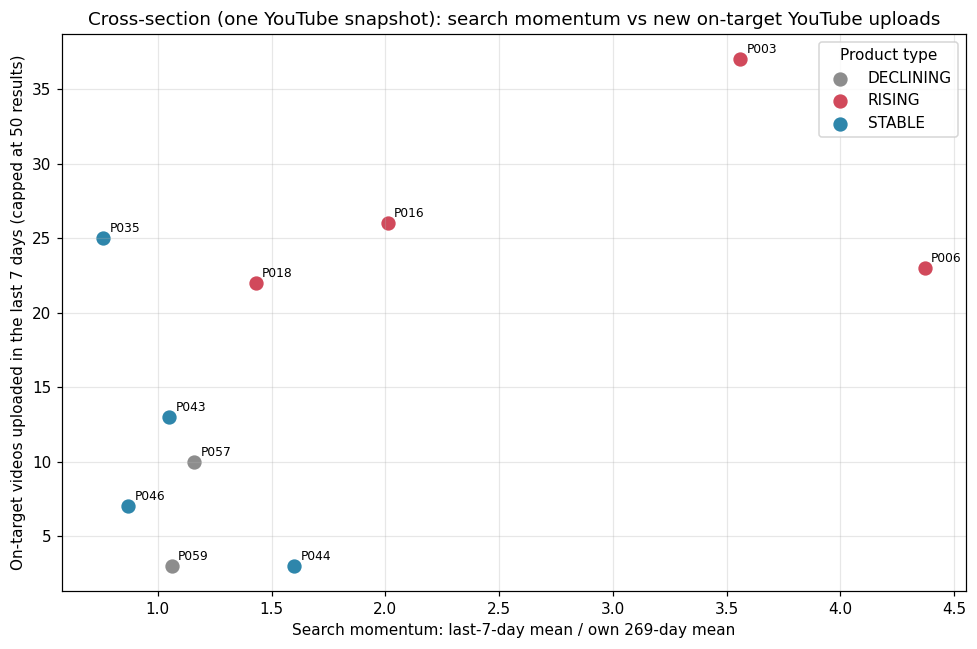

Spearman rank correlation (n = 10 products): 0.38


,product_id,label,product_type,last7_mean,window_mean,momentum,videos_7d_on_target,videos_published_7d
0,P003,P003 Apple iPhone Duo,RISING,5.14,1.44,3.56,37.0,50.0
1,P006,P006 Samsung Galaxy Z Flip 8,RISING,21.86,5.00,4.37,23.0,50.0
2,P016,P016 Poco X8 Power,RISING,3.14,1.56,2.01,26.0,50.0
3,P018,P018 Vivo T5 5G,RISING,24.14,16.89,1.43,22.0,50.0
4,P035,P035 OnePlus 15R,STABLE,38.57,51.04,0.76,25.0,46.0
5,P043,P043 Realme GT 8 Pro,STABLE,34.14,32.62,1.05,13.0,18.0
6,P044,P044 Motorola Edge 70,STABLE,38.57,24.18,1.60,3.0,50.0
7,P046,P046 Oppo Reno 15,STABLE,20.00,22.90,0.87,7.0,34.0
8,P057,P057 Google Pixel 9,DECLINING,72.71,62.87,1.16,10.0,12.0
9,P059,P059 Redmi Note 14 Pro Plus,DECLINING,46.71,43.94,1.06,3.0,37.0


In [5]:
rows = []
for pid, g in complete.groupby("product_id"):
    g = g.sort_values("date")
    recent = df[(df["product_id"] == pid) & (df["youtube_recent_observed"] == True)]
    if recent.empty or g.empty:
        continue
    overall = g["search_interest"].mean()
    last7 = g["search_interest"].iloc[-7:].mean()
    rows.append({"product_id": pid, "label": g["label"].iloc[0], "product_type": g["product_type"].iloc[0],
                 "last7_mean": round(last7, 2), "window_mean": round(overall, 2),
                 "momentum": round(last7 / overall, 2) if overall > 0 else np.nan,
                 "videos_7d_on_target": recent["videos_7d_on_target"].iloc[-1],
                 "videos_published_7d": recent["videos_published_7d"].iloc[-1]})
cross = pd.DataFrame(rows)
plot = cross.dropna(subset=["momentum", "videos_7d_on_target"]) if not cross.empty else cross
if plot.empty:
    print("No product has both Trends data and a YouTube recent-pass observation; chart c skipped.")
else:
    colors = {"RISING": "#d1495b", "STABLE": "#2e86ab", "DECLINING": "#8d8d8d"}
    fig, ax = plt.subplots(figsize=(9, 6))
    for ptype, g in plot.groupby("product_type"):
        ax.scatter(g["momentum"], g["videos_7d_on_target"], s=70, color=colors.get(ptype, "black"), label=ptype)
        for _, r in g.iterrows():
            ax.annotate(r["product_id"], (r["momentum"], r["videos_7d_on_target"]), xytext=(4, 4),
                        textcoords="offset points", fontsize=8)
    ax.set_title("Cross-section (one YouTube snapshot): search momentum vs new on-target YouTube uploads")
    ax.set_xlabel("Search momentum: last-7-day mean / own 269-day mean")
    ax.set_ylabel("On-target videos uploaded in the last 7 days (capped at 50 results)")
    ax.legend(title="Product type")
    fig.tight_layout()
    fig.savefig(FIGURES / "eda_c_momentum_vs_youtube.png", bbox_inches="tight")
    plt.show()
    if len(plot) >= 3:
        print("Spearman rank correlation (n = %d products): %.2f" % (
            len(plot), plot["momentum"].corr(plot["videos_7d_on_target"], method="spearman")))
cross

**Interpretation (cross-section of 10 products, one YouTube snapshot, not a time series):**
- **Weak-to-moderate positive association** (Spearman 0.38, n = 10). The four RISING products sit at the top right: search momentum is 1.4–4.4 times their own average, with 22–37 on-target uploads in the week.
- **OnePlus 15R (P035) is an exception the other way:** 25 on-target uploads despite below-average search momentum (0.76). Review content for an established phone keeps flowing.
- **Motorola Edge 70 (P044) is the clearest anomaly:** momentum 1.6 but only 3 on-target uploads out of 50. Its recent uploads are about sibling models (Edge 70 Pro, Fusion, Max), and its Trends term matches those siblings too. This is consistent with replacing P044.
- **Caveats:** `videos_7d_on_target` comes from one capped search (50 results), so the busiest products may be understated. With n = 10 this is a hint to test once YouTube has a time series, not evidence.

## d. Exploratory, not the project's surge definition: how often does a 7-day mean jump above 1.5x the prior 30-day mean?

**Business question:** how often would a simple spike rule fire for each product type, as a rough sense of base rates?

**Exploratory, not the project's surge definition.** The official surge label is defined by the modelling team. Here a day counts when the mean of the 7 days ending that day is more than 1.5 times the mean of the 30 days before that 7-day window. Days whose prior 30-day mean is 0 are undefined and counted separately.

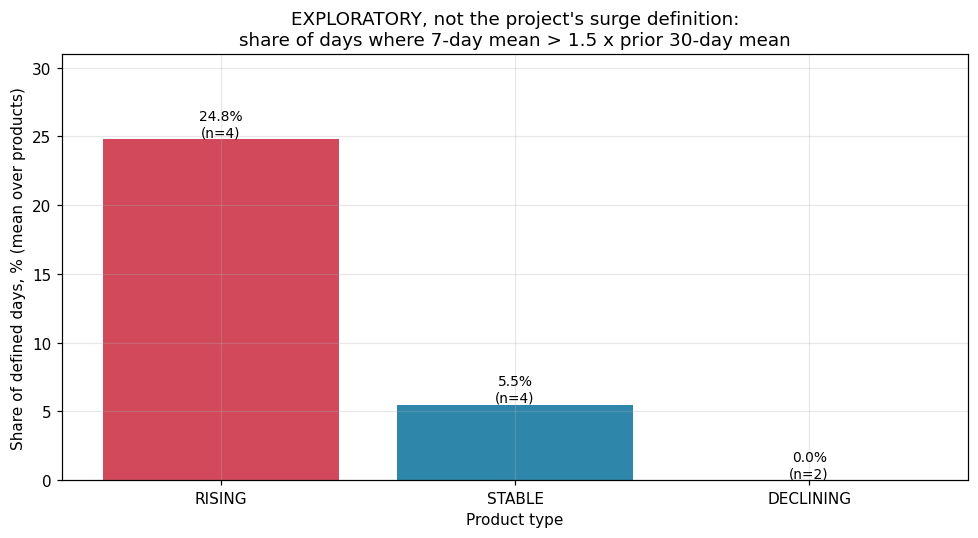

,products,mean_spike_share,products_with_any_spike
product_type,,,
RISING,4,0.248,4
STABLE,4,0.055,2
DECLINING,2,0.000,0


,product_id,product_type,eligible_days,undefined_prior_zero,defined_days,spike_days,spike_share
0,P003,RISING,232,215,17,5,0.294
1,P006,RISING,232,106,126,35,0.278
2,P016,RISING,232,173,59,9,0.153
3,P018,RISING,232,0,232,62,0.267
4,P035,STABLE,232,0,232,0,0.000
5,P043,STABLE,232,0,232,9,0.039
6,P044,STABLE,232,0,232,42,0.181
7,P046,STABLE,232,0,232,0,0.000
8,P057,DECLINING,232,0,232,0,0.000
9,P059,DECLINING,232,0,232,0,0.000


In [6]:
spikes = []
for pid, g in complete.groupby("product_id"):
    s = g.sort_values("date").set_index("date")["search_interest"]
    mean7 = s.rolling(7, min_periods=7).mean()
    prior30 = s.shift(7).rolling(30, min_periods=30).mean()
    eligible = prior30.notna() & mean7.notna()
    defined = eligible & (prior30 > 0)
    hits = defined & (mean7 > 1.5 * prior30)
    spikes.append({"product_id": pid, "product_type": g["product_type"].iloc[0], "eligible_days": int(eligible.sum()),
                   "undefined_prior_zero": int((eligible & (prior30 == 0)).sum()),
                   "defined_days": int(defined.sum()), "spike_days": int(hits.sum()),
                   "spike_share": round(hits.sum() / defined.sum(), 3) if defined.sum() else np.nan})
spikes = pd.DataFrame(spikes)
if spikes.empty:
    print("No products with enough history; chart d skipped.")
else:
    by_type = spikes.groupby("product_type").agg(products=("product_id", "count"),
                                                 mean_spike_share=("spike_share", "mean"),
                                                 products_with_any_spike=("spike_days", lambda s: int((s > 0).sum()))
                                                 ).reindex(TYPE_ORDER)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(by_type.index, by_type["mean_spike_share"] * 100, color=["#d1495b", "#2e86ab", "#8d8d8d"])
    for x, (share, n) in enumerate(zip(by_type["mean_spike_share"], by_type["products"])):
        if pd.notna(share):
            ax.text(x, share * 100, f"{share:.1%}\n(n={n})", ha="center", va="bottom", fontsize=9)
    ax.set_title("EXPLORATORY, not the project's surge definition:\n"
                 "share of days where 7-day mean > 1.5 x prior 30-day mean")
    ax.set_xlabel("Product type")
    ax.set_ylabel("Share of defined days, % (mean over products)")
    top = np.nanmax(by_type["mean_spike_share"].values * 100) if by_type["mean_spike_share"].notna().any() else 1
    ax.set_ylim(0, max(top * 1.25, 1))
    fig.tight_layout()
    fig.savefig(FIGURES / "eda_d_exploratory_spike_share.png", bbox_inches="tight")
    plt.show()
    display(by_type.round(3))
spikes

**Interpretation (exploratory, not the project's surge definition):**
- **RISING:** the simple 1.5× rule fires on 24.8% of defined days for RISING products, and all 4 have at least one hit.
- **STABLE:** 5.5% of days, from 2 of 4 products. Realme GT 8 Pro (P043) is at 3.9%. Motorola Edge 70 (P044) is at 18.1%, high for a STABLE product and plausibly driven by sibling launches inside its broad search term.
- **DECLINING:** 0% for both products.
- **Rule direction:** the rule separates the types in the expected direction.
- **Base rate:** it fires on about a quarter of rising-product days, too often to serve as a surge label on its own.
- **Undefined days:** many RISING days are undefined because the prior 30-day mean is 0. Only 17 of 232 eligible days are defined for iPhone Duo (P003), so its share rests on very few days.
- The official surge label remains the modelling team's decision.

## Limitations
- Pilot only: at most 10 products, one Trends batch (2026-01-08 to 2026-10-03), one YouTube snapshot.
- Trends values are relative to each product's own peak, and pytrends cannot distinguish "<1" from 0.
- The query noise documented in `docs/handoff_task1.md` (sibling models) also affects Trends: base-model terms such as "pixel 9" include sibling searches.
- Nothing here is a model feature or a surge label.